**Importação de Bibliotecas e Base de Dados** (Repositório no GitHub)

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/junior-censi/Inteligencia_Artificial_II/715ae7da4506af49307360552480688030f1bb49/food_delivery_orders_dataset.csv"

base = pd.read_csv(url)
base

,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6
3,ORD_000004,CUS_00007,RES_0001,DRV_0177,2025-10-30 16:54:00,2025-10-30,16,Thursday,0,City_A,...,Low,50,4.3,12,23,31.0,1.0,Completed,NaN,4.1
4,ORD_000005,CUS_00325,RES_0029,DRV_0114,2025-10-15 18:34:00,2025-10-15,18,Wednesday,0,City_B,...,Medium,21,4.0,9,32,42.0,1.0,Completed,NaN,3.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,ORD_049996,CUS_00280,RES_0130,DRV_0112,2025-10-25 12:16:00,2025-10-25,12,Saturday,1,City_B,...,Medium,34,5.0,11,19,21.0,0.0,Completed,NaN,4.4
49996,ORD_049997,CUS_00893,RES_0028,DRV_0036,2025-10-05 19:48:00,2025-10-05,19,Sunday,1,City_B,...,High,49,5.0,9,28,29.0,0.0,Completed,NaN,4.8
49997,ORD_049998,CUS_01618,RES_0001,DRV_0071,2025-10-08 12:18:00,2025-10-08,12,Wednesday,0,City_A,...,High,54,4.1,11,18,16.0,0.0,Completed,NaN,4.7
49998,ORD_049999,CUS_00025,RES_0057,DRV_0103,2025-10-20 17:39:00,2025-10-20,17,Monday,0,City_A,...,High,33,4.0,20,17,27.0,1.0,Completed,NaN,3.8


**Listagem de Colunas** (para filtragem)

In [67]:
for coluna in base.columns:
    print(coluna)

order_id
customer_id
restaurant_id
driver_id
order_timestamp
order_date
order_hour
day_of_week
is_weekend
city
delivery_area
customer_age
customer_type
restaurant_type
restaurant_primary_category
restaurant_rating
items_count
subtotal
discount_percent
tax_amount
service_fee
delivery_fee
order_total
payment_method
tip_amount
distance_km
weather
traffic_level
delivery_partner_experience_months
delivery_partner_rating
restaurant_preparation_time_minutes
estimated_delivery_time_minutes
actual_delivery_time_minutes
late_delivery
order_status
cancellation_reason
customer_rating


**Criação de Nova Base** (colunas de interesse)

In [68]:
colunas = ["distance_km", "weather", "traffic_level", "order_status"]

base_nova = base[colunas]

base_nova

,distance_km,weather,traffic_level,order_status
0,1.1,Rain,Medium,Completed
1,2.5,Cloudy,High,Completed
2,11.8,Cloudy,High,Completed
3,5.4,Cloudy,Low,Completed
4,6.1,Rain,Medium,Completed
...,...,...,...,...
49995,2.9,Cloudy,Medium,Completed
49996,3.8,Clear,High,Completed
49997,2.1,Clear,High,Completed
49998,1.5,Clear,High,Completed


Utilizando **Label Encoder** e **Ordinal Encoder** para Variáveis Nominais / Progressivas

In [69]:
previsores = base_nova.iloc[:, 0:3].values
classe = base_nova.iloc[:, 3].values

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

labelencoder_weather = LabelEncoder()
previsores[:, 1] = labelencoder_weather.fit_transform(previsores[:, 1])

ordinalencoder_traffic = OrdinalEncoder(
    categories=[["Low", "Medium", "High"]]
)

previsores[:, 2] = ordinalencoder_traffic.fit_transform(
    previsores[:, 2].reshape(-1, 1)
).ravel()

previsores = previsores.astype(float)

previsores

array([[ 1.1,  2. ,  1. ],
       [ 2.5,  1. ,  2. ],
       [11.8,  1. ,  2. ],
       ...,
       [ 2.1,  0. ,  2. ],
       [ 1.5,  0. ,  2. ],
       [ 7.3,  2. ,  0. ]])

Importando Bibliotecas e Criando Grupos de **Treinamento e Teste**

In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

previsores_treinamento, previsores_teste, classe_treinamento, classe_teste = train_test_split(
    previsores,
    classe,
    test_size=0.20,
    random_state=42,
    stratify=classe
)

**Instanciando e Treinando a Árvore de Decisão** (com previsões de teste)

In [80]:
from sklearn.tree import DecisionTreeClassifier

arvore_risco_order_status = DecisionTreeClassifier(
    criterion="entropy",
    class_weight="balanced",
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

arvore_risco_order_status.fit(
    previsores_treinamento,
    classe_treinamento
)

previsoes = arvore_risco_order_status.predict(
    previsores_teste
)

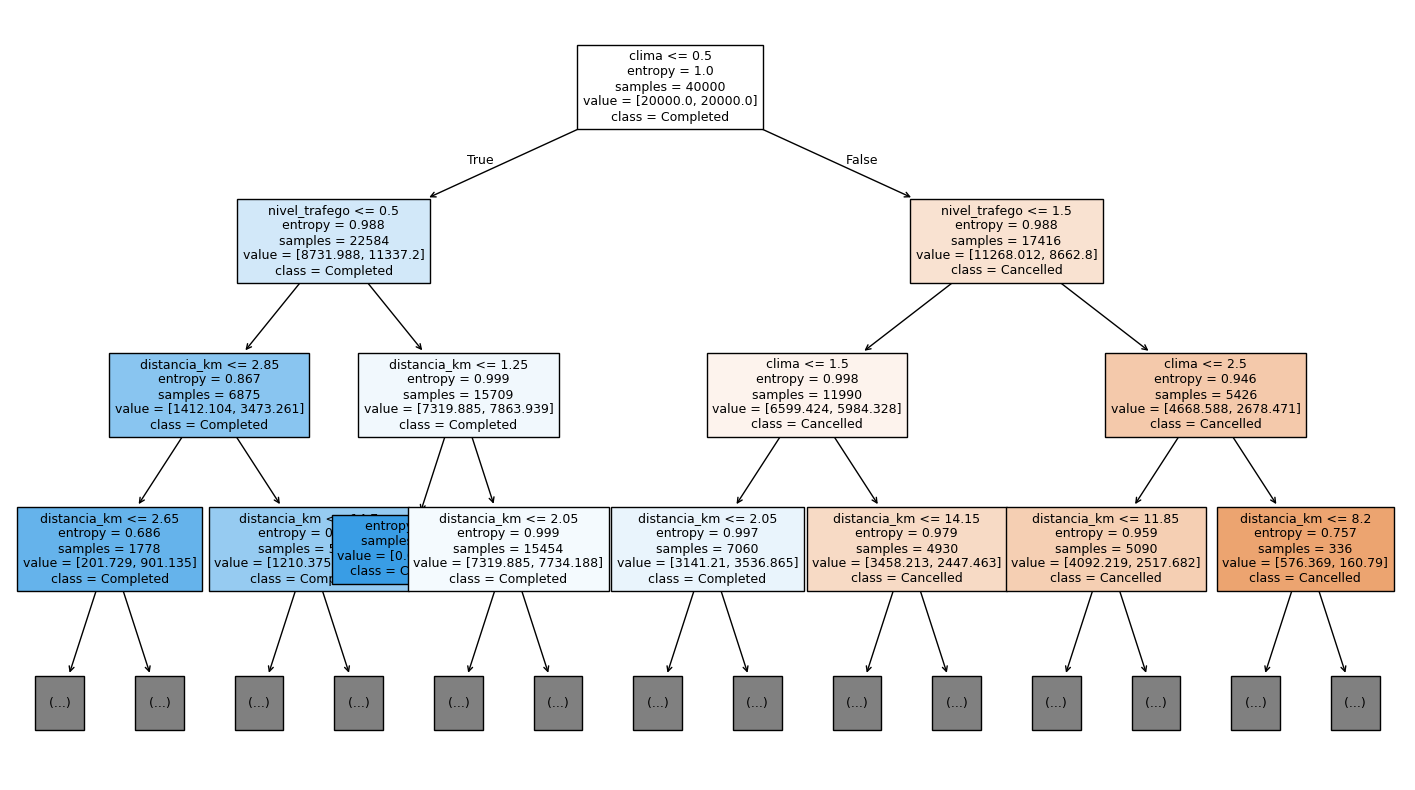

In [81]:
from sklearn import tree

listaPrevisores = [
    "distancia_km",
    "clima",
    "nivel_trafego"
]

plt.figure(figsize=(18, 10))

tree.plot_tree(
    arvore_risco_order_status,
    feature_names=listaPrevisores,
    class_names=arvore_risco_order_status.classes_,
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.show()

**Avaliações** (Acurácia, Matriz de Confusão e Relatório de Classificação)

In [82]:
print("Acurácia:", accuracy_score(classe_teste, previsoes))

print("\nMatriz de confusão:")
print(confusion_matrix(classe_teste, previsoes))

print("\nRelatório de classificação:")
print(classification_report(classe_teste, previsoes))

Acurácia: 0.6497

Matriz de confusão:
[[  76   98]
 [3405 6421]]

Relatório de classificação:
              precision    recall  f1-score   support

   Cancelled       0.02      0.44      0.04       174
   Completed       0.98      0.65      0.79      9826

    accuracy                           0.65     10000
   macro avg       0.50      0.55      0.41     10000
weighted avg       0.97      0.65      0.77     10000



Exibindo Informações da Árvore:

In [78]:
print("Profundidade total:", arvore_risco_order_status.get_depth())
print("Número de folhas:", arvore_risco_order_status.get_n_leaves())

Profundidade total: 25
Número de folhas: 766


Analisando a **Porcentagem de Rótulos** para cada valor das variáveis

In [79]:
pd.crosstab(
    base_nova["weather"],
    base_nova["order_status"],
    normalize="index"
)

order_status,Cancelled,Completed
weather,,
Clear,0.013842,0.986158
Cloudy,0.017877,0.982123
Rain,0.026223,0.973777
Storm,0.036502,0.963498


In [62]:
pd.crosstab(
    base_nova["traffic_level"],
    base_nova["order_status"],
    normalize="index"
)

order_status,Cancelled,Completed
traffic_level,,
High,0.023836,0.976164
Low,0.011738,0.988262
Medium,0.016648,0.983352


In [63]:
base_nova.groupby("order_status")["distance_km"].describe()

,count,mean,std,min,25%,50%,75%,max
order_status,,,,,,,,
Cancelled,868.0,4.870968,2.830528,0.8,2.9,4.1,6.1,20.0
Completed,49132.0,4.728153,2.779258,0.8,2.8,4.1,5.9,20.0


Relações entre as variáveis "weather" e "traffic_level":

In [64]:
tabela = pd.crosstab(
    [base_nova["weather"], base_nova["traffic_level"]],
    base_nova["order_status"],
    normalize="index"
)

tabela

order_status           Cancelled  Completed
weather traffic_level                      
Clear   High            0.018967   0.981033
        Low             0.007352   0.992648
        Medium          0.014885   0.985115
Cloudy  High            0.025189   0.974811
        Low             0.013096   0.986904
        Medium          0.015731   0.984269
Rain    High            0.034217   0.965783
        Low             0.023355   0.976645
        Medium          0.022154   0.977846
Storm   High            0.053528   0.946472
        Low             0.023641   0.976359
        Medium          0.033264   0.966736

**Conclusões - Árvore de Decisão**

*   O conjunto de dados utilizado possui apenas 174 rótulos "Cancelled" para "order_status", enquanto existem 9826 rótulos "Completed". Ou seja, a variável "order_status" é extremamente desbalanceada;

*   Uma árvore convencional apresenta 98% de acurácia de classificação, no entanto, entradas com "order_status = Cancelled" não são identificadas corretamente, conforme constatado na matriz de confusão. A acurácia seria muito semelhante se à todas as entradas fosse atribuído o rótulo "Completed", provando que a acurácia, nesse caso, não é uma boa métrica;

*   A utilização do parâmetro 'class_weight="balanced"' na instanciação da árvore de decisão dá maior ênfase à classificação de entradas com a classe "Cancelled", aumentando seu recall (0,44). Isso, no entanto, gera uma quantia exponencialmente maior de falsos positivos para entradas "Completed", o que diminui drasticamente a acurácia geral da árvore (que se aproxima de 64%, conforme exemplo acima);

*   As últimas análises de variáveis mostram que "weather" e "traffic_level" estão relacionadas ao aumento de concentração de casos em que "order_status" = "Cancelled". Ou seja, clima chuvoso e nível de tráfego alto, de fato, implicam em uma maior probabilidade de que pedidos de entrega sejam cancelados. No entanto, muitas das entregas nessas condições também são bem sucedidas, o que impede que a árvore possa criar uma classificação precisa apenas com base nessas variáveis.

Aplicando a **Random Forest**:

In [87]:
floresta_balanceada = RandomForestClassifier(
    n_estimators=100,
    max_features=3,
    criterion='entropy',
    class_weight='balanced',
    random_state=42
)

floresta_balanceada.fit(
    previsores_treinamento,
    classe_treinamento
)

previsoes_rf_balanceada = floresta_balanceada.predict(
    previsores_teste
)

print("### Resultados Random Forest Balanceada ###")

print("\nAcurácia:")
print(
    accuracy_score(
        classe_teste,
        previsoes_rf_balanceada
    )
)

print("\nMatriz de confusão:")
print(
    confusion_matrix(
        classe_teste,
        previsoes_rf_balanceada
    )
)

print("\nRelatório de classificação:")
print(
    classification_report(
        classe_teste,
        previsoes_rf_balanceada
    )
)

### Resultados Random Forest Balanceada ###

Acurácia:
0.7776

Matriz de confusão:
[[  40  134]
 [2090 7736]]

Relatório de classificação:
              precision    recall  f1-score   support

   Cancelled       0.02      0.23      0.03       174
   Completed       0.98      0.79      0.87      9826

    accuracy                           0.78     10000
   macro avg       0.50      0.51      0.45     10000
weighted avg       0.97      0.78      0.86     10000



**Conclusões - Random Forest**

*   Comparada à Árvore de Decisão balanceada, a Random Forest balanceada identifica uma proporção menor dos cancelamentos (recall = 0,23), porém mantém um melhor equilíbrio no desempenho geral, alcançando acurácia de aproximadamente 77,8%;

*   Foram realizados dois testes, utilizando n_estimators igual a 20 e 100. Ambos apresentaram relatórios de classificação bastante semelhantes, indicando que o simples aumento do número de árvores não é suficiente para solucionar a dificuldade de classificação da classe minoritária (Cancelled);

*   Por fim, observa-se que as variáveis analisadas apresentam alguma relação com a ocorrência de cancelamentos, especialmente em determinadas combinações de clima e nível de tráfego. Entretanto, a classe Cancelled representa uma parcela muito pequena do conjunto de dados e as características disponíveis não permitem uma separação suficientemente clara entre pedidos cancelados e concluídos. Esse forte desbalanceamento, aliado ao limitado poder discriminativo das variáveis, dificulta a obtenção de classificações precisas tanto pela Árvore de Decisão quanto pela Random Forest.